In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr

## Cargamos los datos

In [23]:
df = pd.read_parquet(r"D:\DDAA\SimuladorEmpresarial\RRHH_220925_clean.parquet")
#pd.set_option("display.max_rows", None)
#pd.set_option("display.max_columns", None)
#df
df.dtypes

ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure                int64
Education                  string[python]
Son                                 int64
Social_drinker                      int64
Social_smoker                       int64
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Education_numeric                   int64
Month_absence_order                 int64
Day_week_order                    

# Plan de análisis

## Objetivo del análisis 

Determinar qué características de los empleados están asociadas con un mayor desempeñoo laboral.

Para tener una medida de desempeño laboral consideraremos lo siguiente (para cada trabajador): el promedio de hit_target, la suma de horas de absentismo (o el recuento de absencias), si han tenido alguna falta disciplinaria o no, el número de faltas injustificadas. 

## ¿Cómo integrar toda esta información?

### Opción 1: clustering 

Podemos hacer clusters con estas variables y tendremos distintos grupos de trabajadores según su desempeño. A continuación, miraremos las características personales de cada grupo para intentar extraer conclusiones. 

### Opción 2: creación de medida de desempeño

En base a información sobre otras empresas, dar un peso a las distintas variables para obtener una medida de desempeño. 

## Respondiendo a la pregunta "¿Cómo afectan las catacterísticas personales al desempeño?"

### Análisis descriptivo

Ver qué características tienen los distintos clusters

### Modelo predictivo

Creamos un modelo con la combinación de características personales que nos permitan explicar en mayor medida la asignación de un trabajador a un cluster. 

Esto nos permitirá predecir a qué grupo de trabajadores pertenecerá un nuevo empleado en base a sus características personales.

# Cálculo de variables a utilizar en el clustering

In [24]:
pd.set_option("display.max.columns", None)
# Calculamos la media de hit target de cada trabajador 
df['Hit_target_avg'] = df.groupby('ID')['Hit_target'].transform('mean')

# Calculamos la media de Work_load_Average_day de cada trabajador
df['Work_load_Average_day'] = df.groupby('ID')['Work_load_Average_day'].transform('mean')

# Calcular número d'absències per treballador
df['count_absenteeism'] = (
    (df['Absenteeism_hours'] != 0)  
    .groupby(df['ID'])              
    .transform('sum')               
)

# Calcular quantes absències injustificades té cada treballador
df["unjustified_absence"] = (
    (df["Reason_absence"] == "26")
    .groupby(df["ID"])
    .transform("sum")
)

# Suma total d'hores d'absència per treballador
df["sum_absenteeism_hours"] = df.groupby("ID")["Absenteeism_hours"].transform("sum")

# Determinem si en algun moment han tingut una falta disciplinària
df["Disciplinary_failure"] = df.groupby("ID")["Disciplinary_failure"].transform(lambda x: int(x.max()))

# Ens quedem amb una única observació per treballador
df = df.drop_duplicates(subset=["ID"], keep="last").reset_index(drop=True)

# Eliminem les variables que ja han perdut sentit
df = df.drop(columns=["Reason_absence","Month_absence", "Day_week", "Seasons","Hit_target","Absenteeism_hours","Education_numeric","Month_absence_order","Day_week_order","Seasons_order"])

# Passar les binàries a boolean
cat_vars = ['Social_drinker', 'Social_smoker', 'Disciplinary_failure']
for col in cat_vars:
    df[col] = df[col].astype(bool)

df.head()

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,94.875000,8,0,72.0
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,97.500000,2,0,16.0
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,95.600000,10,0,42.0
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,96.142857,7,0,34.0
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,95.166667,6,0,25.0


In [25]:
df.dtypes

ID                                  int64
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Disciplinary_failure                 bool
Education                  string[python]
Son                                 int64
Social_drinker                       bool
Social_smoker                        bool
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Hit_target_avg                    float64
count_absenteeism                   int64
unjustified_absence                 Int64
sum_absenteeism_hours             float64
dtype: object

In [26]:
# Què utilitzem, count d'absències o suma d'hores d'absència?

# Mirem la correlació per si de cas no fos massa alta i poguéssim utilitzar les dues:

from scipy.stats import spearmanr
r, pval = spearmanr(df["count_absenteeism"], df["sum_absenteeism_hours"])

print(f"Spearman correlation (r): {r:.3f}")
print(f"P-value: {pval:.3e}")


Spearman correlation (r): 0.772
P-value: 4.059e-28


# Clustering

In [27]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Seleccionamos las columnas
dfClus = df[["ID","Hit_target_avg", "Disciplinary_failure", "sum_absenteeism_hours", "unjustified_absence"]].copy()

# Escalamos solo las columnas numéricas
num_cols = ["Hit_target_avg", "sum_absenteeism_hours", "unjustified_absence"]
X_num = dfClus[num_cols].values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Reconstruimos X agregando la columna categórica (falta disciplinaria)
X = np.hstack([X_num_scaled, dfClus[["Disciplinary_failure"]].values])

# Ahora la columna categórica es la última
cat_cols = [3]

# Entrenar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Huang')
clusters = kproto.fit_predict(X, categorical=cat_cols)

# Guardar clusters en el DataFrame
dfClus["cluster"] = clusters.astype(int)

resumen = dfClus.groupby("cluster").agg({
    "Hit_target_avg": "mean",
    "Disciplinary_failure": "mean",   # será la proporción de 1s
    "sum_absenteeism_hours": "mean",
    "unjustified_absence": "mean",
    "cluster": "count"                 # cantidad de empleados por cluster
}).rename(columns={"cluster": "n_empleados"})
print(resumen)

# Imprimir cost
print("Cost del clustering:", kproto.cost_)

# Ver la distribución de clusters
print(dfClus["cluster"].value_counts())

# Opcional: mostrar centroides
print("Centroides:")
print(kproto.cluster_centroids_)

         Hit_target_avg  Disciplinary_failure  sum_absenteeism_hours  \
cluster                                                                
0             94.621384              0.615385             270.230769   
1             93.381217              1.000000             286.000000   
2             90.574775              0.135135               8.135135   
3             96.480106              0.084337              14.265060   

         unjustified_absence  n_empleados  
cluster                                    
0                        1.0           13  
1                   6.333333            3  
2                   0.054054           37  
3                   0.012048           83  
Cost del clustering: 120.4814272332333
cluster
3    83
2    37
0    13
1     3
Name: count, dtype: int64
Centroides:
[[-1.80624556e-03  2.39934170e+00  6.97914028e-01  1.00000000e+00]
 [-3.69361969e-01  2.56589296e+00  5.70999628e+00  1.00000000e+00]
 [-1.20112372e+00 -3.68856558e-01 -1.91053265e-01  0

In [28]:
# Fem una nova columna al df per indicar a quin cluster pertany cada treballador: 

df = df.merge(dfClus[["ID", "cluster"]].drop_duplicates(), on="ID", how="left")
df.head(20)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours,cluster
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,94.875000,8,0,72.0,3
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,97.500000,2,0,16.0,3
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,95.600000,10,0,42.0,3
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,96.142857,7,0,34.0,3
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,95.166667,6,0,25.0,3
5,14,155.0,12.0,14.0,34.0,299.354379,False,High school,2,True,False,0,95.0,196.0,25.0,95.689655,29,0,476.0,0
6,26,300.0,26.0,13.0,43.0,247.717000,False,High school,2,True,True,1,77.0,175.0,25.0,95.400000,5,0,83.0,3
7,10,361.0,52.0,3.0,28.0,258.764348,False,High school,1,True,False,4,80.0,172.0,27.0,94.000000,23,0,178.0,0
8,32,289.0,48.0,29.0,49.0,309.128200,False,High school,0,False,False,2,108.0,172.0,36.0,92.600000,5,0,16.0,2
9,9,228.0,14.0,16.0,58.0,249.042250,False,High school,2,False,False,1,65.0,172.0,22.0,95.875000,8,0,262.0,0


In [29]:
# Diccionari de mapeig
cluster_map = {
    3: "Productius i estables",
    2: "Estables",
    1: "Ausents",
    0: "Critics"
}

# Aplicar el canvi
df['cluster'] = df['cluster'].map(cluster_map)


# Com varien les característiques personals a través dels diferents clusters?

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, chi2_contingency

# Suposant que df és el teu DataFrame

# Variables numèriques (excloem 'ID' i 'cluster')
num_vars = ['Transportation_expense', 'Distance_Residence_Work', 'Service_time',
            'Age', 'Work_load_Average_day', 'Son',
            'Pet', 'Weight', 'Height', 'Body_mass_index']

# Variables categòriques/binàries
cat_vars = ['Education', 'Social_drinker', 'Social_smoker']


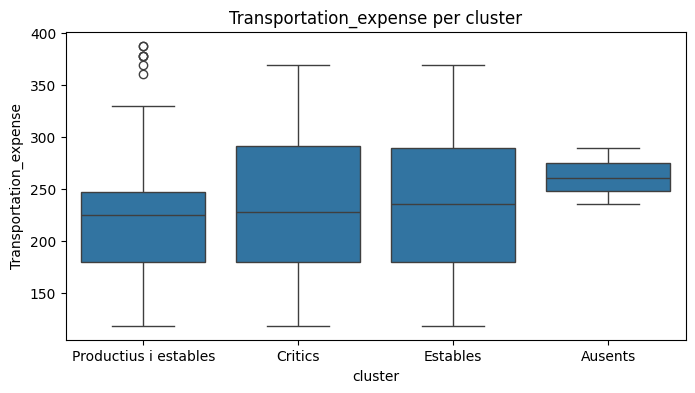

Kruskal-Wallis test per Transportation_expense: H=5.89, p=0.1170



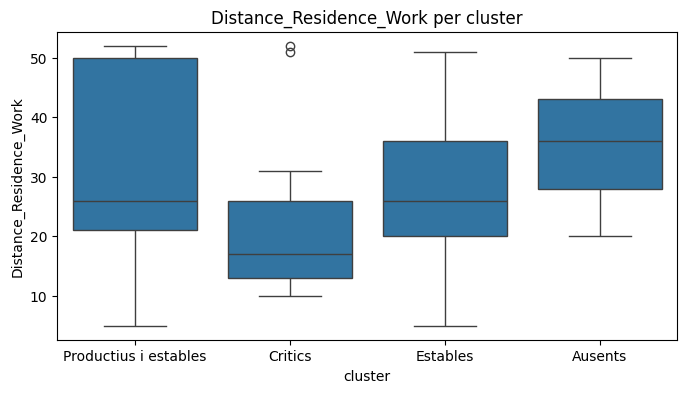

Kruskal-Wallis test per Distance_Residence_Work: H=3.42, p=0.3314



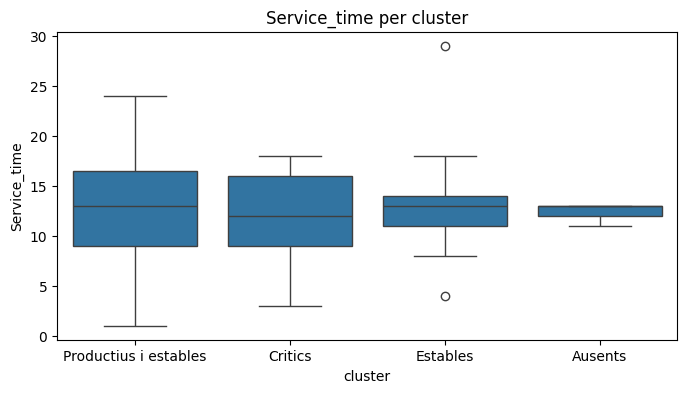

Kruskal-Wallis test per Service_time: H=0.13, p=0.9875



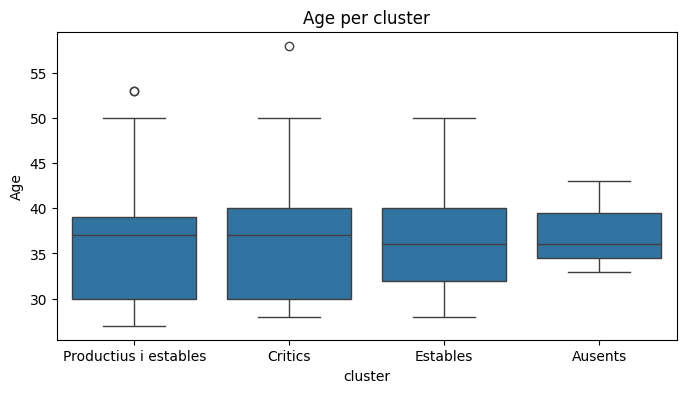

Kruskal-Wallis test per Age: H=0.16, p=0.9838



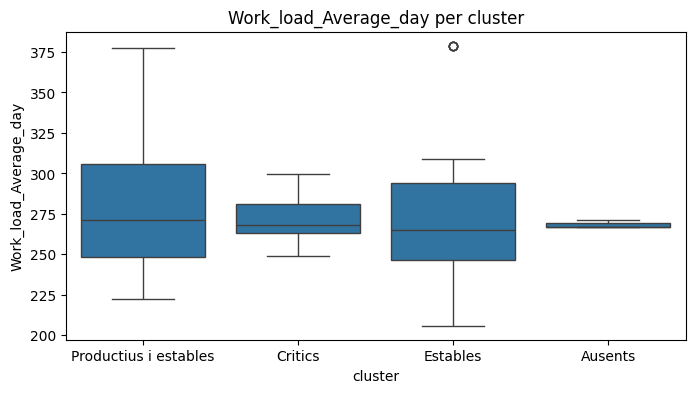

Kruskal-Wallis test per Work_load_Average_day: H=0.24, p=0.9706



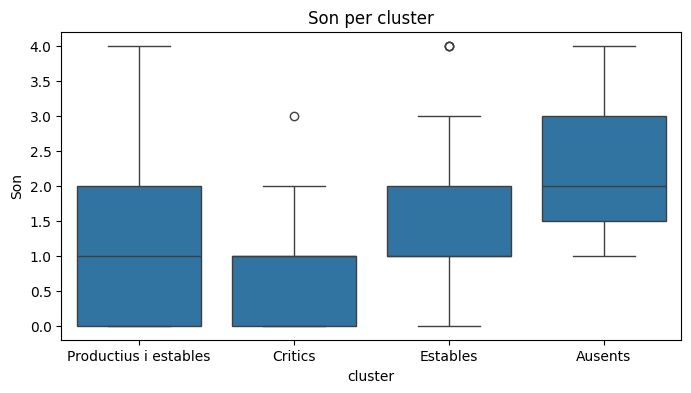

Kruskal-Wallis test per Son: H=6.73, p=0.0812



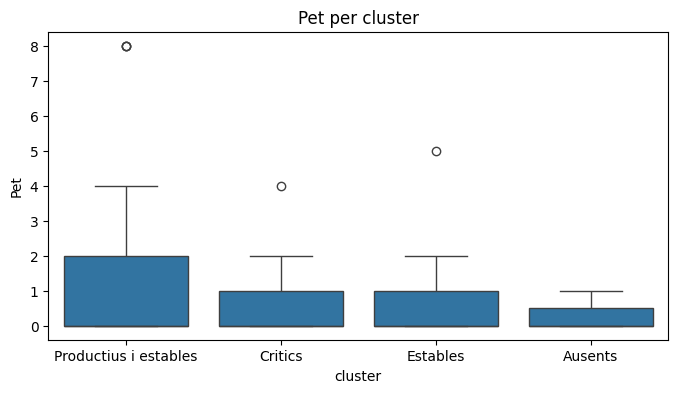

Kruskal-Wallis test per Pet: H=0.42, p=0.9361



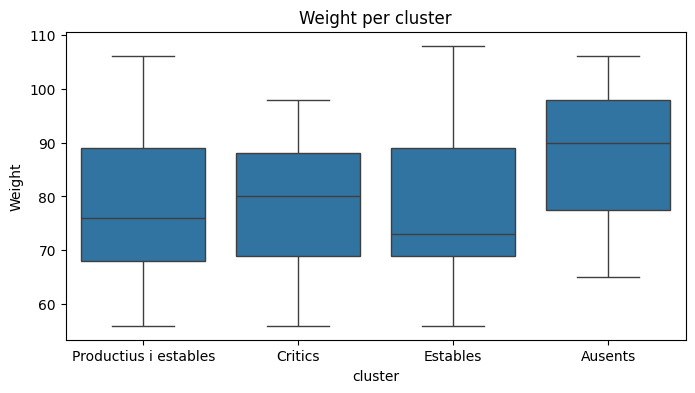

Kruskal-Wallis test per Weight: H=1.38, p=0.7104



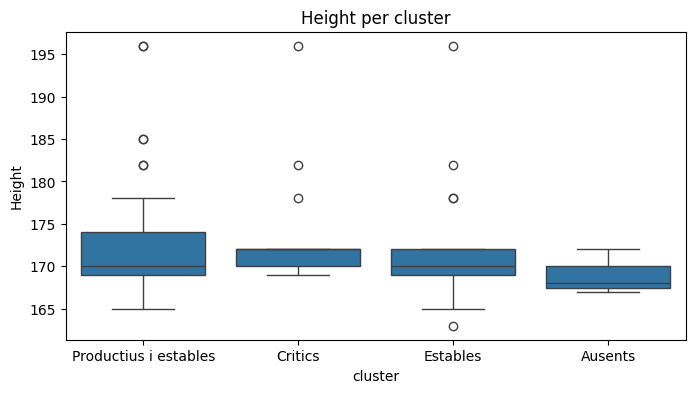

Kruskal-Wallis test per Height: H=7.00, p=0.0719



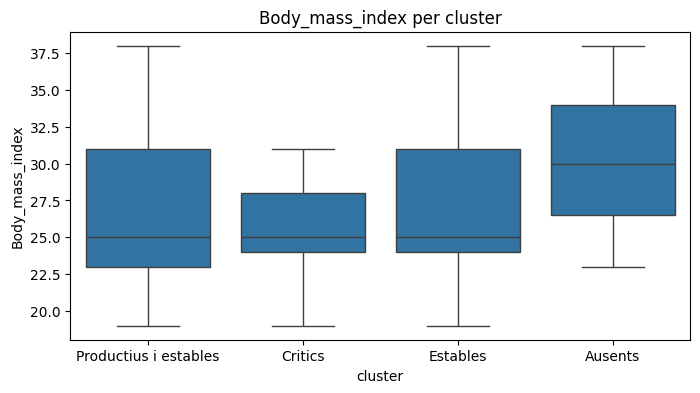

Kruskal-Wallis test per Body_mass_index: H=1.58, p=0.6647



In [31]:
for var in num_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='cluster', y=var, data=df)
    plt.title(f'{var} per cluster')
    plt.show()
    
    # Test de Kruskal-Wallis
    groups = [df[df['cluster']==c][var] for c in df['cluster'].unique()]
    stat, p = kruskal(*groups)
    print(f"Kruskal-Wallis test per {var}: H={stat:.2f}, p={p:.4f}\n")


Taula de contingència per Education:
cluster        Ausents  Critics  Estables  Productius i estables
Education                                                       
Graduate             0        1         5                      6
High school          3       10        30                     67
Master/Doctor        0        0         0                      1
Postgraduate         0        2         2                      9

Chi-square test per Education: chi2=3.80, p=0.9238



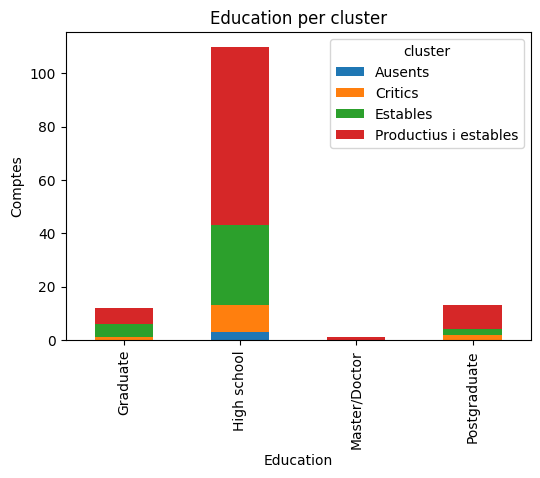

Taula de contingència per Social_drinker:
cluster         Ausents  Critics  Estables  Productius i estables
Social_drinker                                                   
False                 0        6        17                     41
True                  3        7        20                     42

Chi-square test per Social_drinker: chi2=2.87, p=0.4119



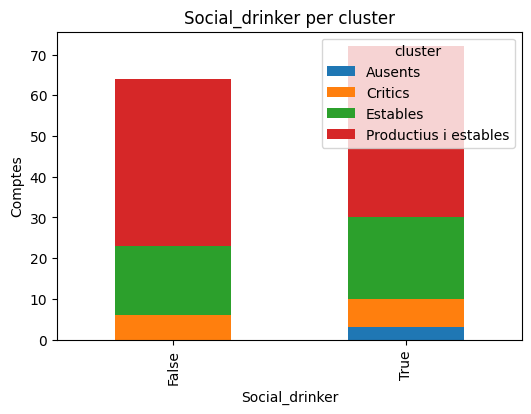

Taula de contingència per Social_smoker:
cluster        Ausents  Critics  Estables  Productius i estables
Social_smoker                                                   
False                3       13        32                     71
True                 0        0         5                     12

Chi-square test per Social_smoker: chi2=2.61, p=0.4555



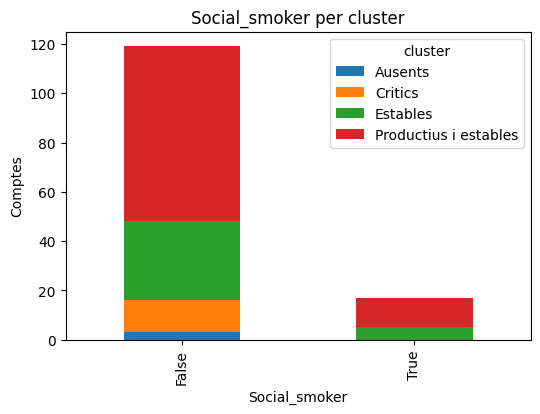

In [32]:
for var in cat_vars:
    contingency = pd.crosstab(df[var], df['cluster'])
    print(f"Taula de contingència per {var}:\n{contingency}\n")
    
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"Chi-square test per {var}: chi2={chi2:.2f}, p={p:.4f}\n")
    
    # Opcional: visualització
    contingency.plot(kind='bar', stacked=True, figsize=(6,4))
    plt.title(f'{var} per cluster')
    plt.ylabel('Comptes')
    plt.show()


# Opción 2: crear una medida de desempeño

En base a la información encontrada, hemos decidido dar el siguiente peso a cada variable: 

Desempeno=(0.45×hit_target_avg)+(0.20×total_horas)+(0.20×faltas_injustificades)+(0.15×f_disciplinaria). Pero atención porque la primera es positiva y el resto negativas. Además, tienen escalas muy distintas, por lo que se tendrán que normalizar. 

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Variables a considerar
vars_pos = ['Hit_target_avg']  # positiva
vars_neg = ['sum_absenteeism_hours', 'unjustified_absence', 'Disciplinary_failure']  # negativas

# Normalizar todas entre 0 y 1
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[vars_pos + vars_neg]),
                         columns=vars_pos + vars_neg,
                         index=df.index)

# Invertir las negativas para que 1 = mejor desempeño
for col in vars_neg:
    df_scaled[col] = 1 - df_scaled[col]

# Calcular medida de desempeño (0–100)
df['medida_desempeno'] = (0.45*df_scaled['Hit_target_avg'] +
                          0.20*df_scaled['sum_absenteeism_hours'] +
                          0.20*df_scaled['unjustified_absence'] +
                          0.15*df_scaled['Disciplinary_failure']) *100


df.head(10)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours,cluster,medida_desempeno
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,94.875000,8,0,72.0,Productius i estables,86.662290
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,97.500000,2,0,16.0,Productius i estables,95.577731
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,95.600000,10,0,42.0,Productius i estables,89.735294
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,96.142857,7,0,34.0,Productius i estables,91.428571
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,95.166667,6,0,25.0,Productius i estables,89.366246
5,14,155.0,12.0,14.0,34.0,299.354379,False,High school,2,True,False,0,95.0,196.0,25.0,95.689655,29,0,476.0,Critics,71.724138
6,26,300.0,26.0,13.0,43.0,247.717000,False,High school,2,True,True,1,77.0,175.0,25.0,95.400000,5,0,83.0,Productius i estables,87.512605
7,10,361.0,52.0,3.0,28.0,258.764348,False,High school,1,True,False,4,80.0,172.0,27.0,94.000000,23,0,178.0,Critics,80.021008
8,32,289.0,48.0,29.0,49.0,309.128200,False,High school,0,False,False,2,108.0,172.0,36.0,92.600000,5,0,16.0,Estables,83.327731
9,9,228.0,14.0,16.0,58.0,249.042250,False,High school,2,False,False,1,65.0,172.0,22.0,95.875000,8,0,262.0,Critics,81.179097


## Correlación de las características personales con la medida de desempeño

Correlaciones significativas con medida_desempeno:
                             rho      pval
Transportation_expense -0.212348  0.013069
Work_load_Average_day  -0.214450  0.012174


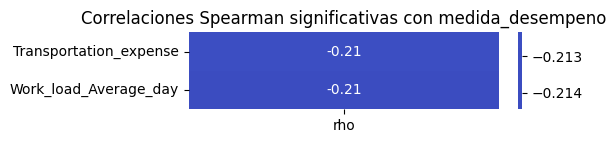

In [34]:
# Variables de interés
vars_interes = [
    "Transportation_expense","Distance_Residence_Work","Service_time","Age",
    "Work_load_Average_day","Son","Weight","Height","Body_mass_index"
]

target = "medida_desempeno"
results = {}

# Calcular rho y p-valor para cada variable de interés
for col in vars_interes:
    rho, pval = spearmanr(df[target], df[col], nan_policy="omit")
    results[col] = {"rho": rho, "pval": pval}

# Convertimos a DataFrame
res_df = pd.DataFrame(results).T

# Filtramos las significativas (p < 0.05)
sig_res = res_df[res_df["pval"] < 0.05].sort_values("rho", ascending=False)

# Mostrar resultados
print("Correlaciones significativas con medida_desempeno:")
print(sig_res)

# Graficar heatmap solo de las significativas
if not sig_res.empty:
    plt.figure(figsize=(5, len(sig_res) * 0.5))
    sns.heatmap(sig_res[["rho"]], annot=True, cmap="coolwarm", center=0)
    plt.title("Correlaciones Spearman significativas con medida_desempeno")
    plt.show()
else:
    print("⚠️ Ninguna correlación significativa encontrada.")


## Relación entre desempeño y variables categóricas

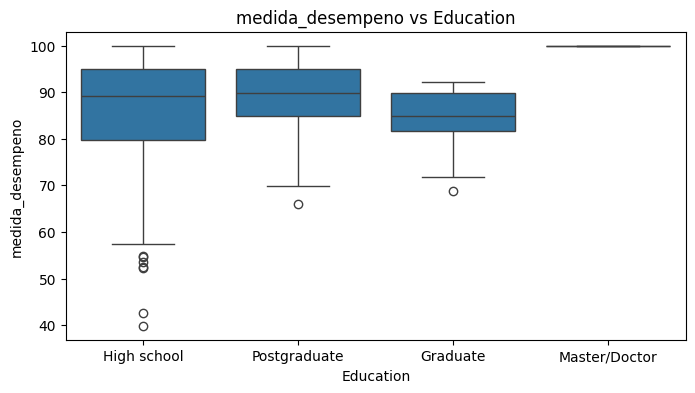

Education - p-value Kruskal-Wallis: 0.2564


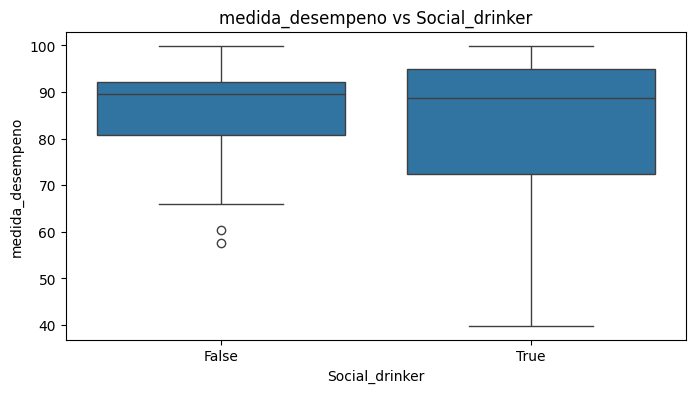

Social_drinker - p-value Mann-Whitney U: 0.9635


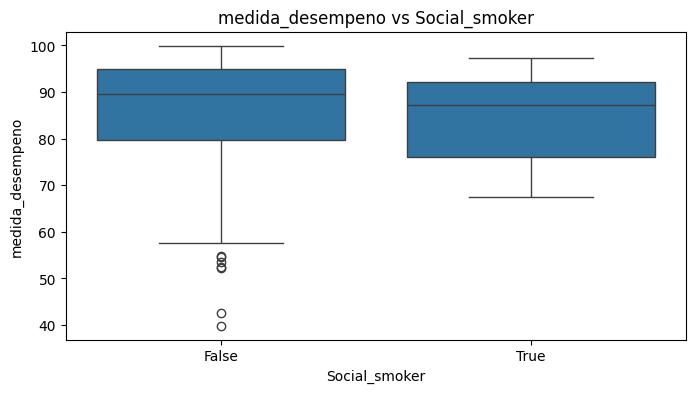

Social_smoker - p-value Mann-Whitney U: 0.6008


In [35]:
cat_vars = ['Education', 'Social_drinker', 'Social_smoker']

for col in cat_vars:
    # Boxplots
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y=target, data=df)
    plt.title(f"{target} vs {col}")
    plt.show()
    
    # Separar en grups
    groups = [group[target].values for name, group in df.groupby(col)]
    
    # Kruskal-Wallis per Education
    if col == "Education" and len(groups) > 1:
        kruskal = stats.kruskal(*groups)
        print(f"{col} - p-value Kruskal-Wallis: {kruskal.pvalue:.4f}")
    
    # Mann-Whitney U per variables binàries
    elif len(groups) == 2:
        mannwhitney = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
        print(f"{col} - p-value Mann-Whitney U: {mannwhitney.pvalue:.4f}")
    else:
        print(f"{col} - No s'ha aplicat test estadístic")


## Modelo predictivo

In [36]:
# Passar les categòriques/binomials a object
cat_vars = ['Education', 'Social_drinker', 'Social_smoker']
for col in cat_vars:
    df[col] = df[col].astype(str).str.strip()

In [37]:
import numpy as np
import statsmodels.formula.api as smf

# 1. Escalar la resposta a [0,1]
df["medida_desempeno_scaled"] = df["medida_desempeno"] / 100

# 2. Ajustar els valors per evitar 0 i 1 exactes (sinó el logit peta)
eps = 1e-6
df["medida_desempeno_scaled"] = df["medida_desempeno_scaled"].clip(eps, 1 - eps)

# 3. Transformació logit
df["medida_desempeno_logit"] = np.log(df["medida_desempeno_scaled"] / (1 - df["medida_desempeno_scaled"]))

# 4. Definir la fórmula del model amb predictors
formula = 'medida_desempeno_logit ~  Transportation_expense + Distance_Residence_Work + Service_time + Age + Work_load_Average_day + Son + Weight + Height + Body_mass_index + Education + Social_drinker + Social_smoker'

# 5. Ajustar regressió lineal (OLS)
model = smf.glm(formula, data=df).fit()

# 6. Resultats
print(model.summary())

# 7. Si vols prediccions en l'escala original (0-100):
df["pred_logit"] = model.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                   Generalized Linear Model Regression Results                    
Dep. Variable:     medida_desempeno_logit   No. Observations:                  136
Model:                                GLM   Df Residuals:                      121
Model Family:                    Gaussian   Df Model:                           14
Link Function:                   Identity   Scale:                          2.5416
Method:                              IRLS   Log-Likelihood:                -248.46
Date:                    Wed, 01 Oct 2025   Deviance:                       307.54
Time:                            11:23:56   Pearson chi2:                     308.
No. Iterations:                         3   Pseudo R-squ. (CS):             0.1673
Covariance Type:                nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------